# 树模型与集成方法

本章介绍**基于树的方法**（Tree-Based Methods），这是一类在金融建模中被广泛使用的机器学习工具。与回归模型相比，树模型的特别之处在于它能够自动发现变量之间的非线性关系和交互效应，并且可以同时处理连续变量与分类变量。

---

**本章使用的数据集**

全章使用同一个数据集：`Default`，来自 ISLP 包。该数据集模拟 10,000 名信用卡持卡人的违约情况，包含以下变量：

| 变量 | 类型 | 说明 |
|---|---|---|
| `default` | 二值分类（Yes/No） | 是否违约，本章的主要预测目标 |
| `student` | 二值分类（Yes/No） | 是否为在校学生 |
| `balance` | 连续变量（美元） | 信用卡月均余额 |
| `income` | 连续变量（美元） | 年收入 |

这个数据集结构干净，变量类型齐全（连续变量、二值分类变量、目标分类变量），且背景与信贷风险直接相关，适合从头到尾贯穿本章所有方法。

![数据集概览](./figs/ml_tree_fig01_data_overview.png){width="92%"}

**图 1** 展示了 `Default` 数据集中两个连续变量的分布。从左图可以看到，违约用户（橙色）的信用卡余额明显高于未违约用户（蓝色）；右图则显示两组用户的年收入分布高度重叠，说明收入对违约的区分能力相对较弱。这两个特征将在后面的树模型分析中得到定量验证。

---

## 第一部分　从分组均值到决策树：建立直觉

### 1.1　一个朴素的问题：分组预测

在学习任何新方法之前，我们先问一个最简单的问题：**用学生身份（`student`）来预测信用卡余额（`balance`），应该怎么做？**

最直接的答案是：把样本按 `student` 分成两组，分别计算各组的 `balance` 均值，然后用组均值作为该组所有人的预测值。

$$
\hat{y}_i =
\begin{cases}
\bar{y}_{\text{非学生}} & \text{若 } \texttt{student}_i = \text{No} \\
\bar{y}_{\text{学生}}   & \text{若 } \texttt{student}_i = \text{Yes}
\end{cases}
$$

在 `Default` 数据中，计算结果如下：

$$
\bar{y}_{\text{非学生}} \approx 803 \text{ 美元}, \qquad
\bar{y}_{\text{学生}}   \approx 988 \text{ 美元}
$$

这说明学生群体的信用卡余额平均比非学生高约 185 美元。

![分组均值与虚拟变量回归](./figs/ml_tree_fig02_groupmean_bar.png){width="92%"}

**图 2（左）** 用条形图和散点抖动展示了两组的 `balance` 分布与均值。**图 2（右）** 则揭示了一个重要事实：上述分组均值与运行一次虚拟变量 OLS 回归得到的拟合值**完全相同**。

### 1.2　虚拟变量回归：你已经在建模了

设虚拟变量 $D_i = \mathbf{1}[\texttt{student}_i = \text{Yes}]$，运行 OLS 回归

$$
\texttt{balance}_i = \alpha + \beta \cdot D_i + u_i
$$

估计结果为

$$
\hat{\alpha} \approx 803, \qquad \hat{\beta} \approx 185
$$

对应的拟合值为

$$
\hat{y}_i =
\begin{cases}
803  & D_i = 0 \text{（非学生）} \\
988  & D_i = 1 \text{（学生）}
\end{cases}
$$

**这与我们直接计算的分组均值完全一致。**

在 Stata 中，这个操作对应：
```stata
reg balance student_bin
margins, at(student_bin=(0 1))
```

`margins` 输出的预测值就是各组的条件均值 $E[\texttt{balance} \mid \texttt{student}]$。

这个等价性并不是巧合，而是 OLS 的基本性质：**当预测变量只有一个二值虚拟变量时，OLS 拟合值等于各组的样本均值**。（等价性的代数证明见附录 A。）

### 1.3　用树的语言重新描述

现在，我们把上面的操作用一种新的语言重新描述。

![分组均值等价树结构](./figs/ml_tree_fig03_tree_equiv.png){width="92%"}

**图 3（右）** 画出了一棵最简单的决策树：

- **根节点**（root node）：提出一个问题，这个人是学生吗（`student = Yes`）？
- **分支**（branch）：根据回答分为两条路径，No 走左边，Yes 走右边
- **叶节点**（leaf node，也称终节点）：每条路径的终点，给出预测值——803 或 988

这棵树的叶节点预测值，恰好就是对应分组的 `balance` 均值。

::: {.callout-tip}
### 核心认识
你刚才做的分组均值计算，本质上就是一棵拥有两个叶节点的决策树。决策树只是提供了一种更系统、更灵活的方式来做这件事——它可以处理多个变量，自动寻找最优的分割边界，以及进行多层嵌套的分割。
::: 

### 1.4　为什么不直接用线性回归？

既然分组均值可以用虚拟变量回归实现，为什么还需要树？

原因在于：**线性回归假设每个变量对结果的影响是独立的、线性叠加的**，而真实世界中的关系往往更复杂。

考虑一个金融场景：用 `balance`（信用卡余额）和 `student`（是否学生）预测违约概率。如果违约风险的规律是：

- 学生群体中：余额高于某个阈值才显著影响违约（因为学生收入不稳定，高余额意味着更大压力）
- 非学生群体中：余额对违约的影响在较低余额时已经开始显现

这种分组的非线性效应，线性回归很难准确捕捉，而决策树天然能够处理：它先按 `student` 分割，在每个子组内再按 `balance` 的最优阈值继续分割，从而为不同群体找到不同的决策边界。

![RSS 随切分点变化](./figs/ml_tree_fig02_linear_tree_boundary.svg){width="80%"}

**图：线性分类边界与决策树分类边界的比较。**

图中黄色和绿色区域表示两个类别。上排展示的是一个真实分类边界为线性的情形：左图中，线性模型可以直接用一条直线刻画真实边界；右图中，决策树只能通过平行于坐标轴的水平切分和垂直切分来逼近该边界，因此形成阶梯状的分类结构。

下排展示的是一个真实分类边界为非线性的情形。左图中，线性模型只能给出一条直线，难以刻画右下方矩形区域对应的类别结构；右图中，决策树通过两个轴平行切分即可较好地表示该非线性边界。这说明，决策树并不依赖线性函数形式，而是通过递归划分特征空间来形成分类规则。其优势在于能够捕捉局部、非线性和交互型的分类模式；但在真实边界接近线性时，简单线性模型反而可能更简洁、更平滑，也更容易解释。

::: {.callout-note}
### 条件期望与分组预测

设 $D$ 为二值变量。对 $Y$ 的最优预测（在均方误差意义下）是条件期望 $E[Y \mid D]$。

当 $D = 0$ 时，最优预测是 $E[Y \mid D = 0]$；当 $D = 1$ 时，最优预测是 $E[Y \mid D = 1]$。

在实践中，总体条件期望 $E[Y \mid D]$ 不可知，我们用样本条件均值 $\bar{Y}_{D=0}$ 和 $\bar{Y}_{D=1}$ 来估计它。这正是分组均值预测的理论基础，也是决策树叶节点预测值的统计含义。
:::

---

## 第二部分　回归树

### 2.1　从一刀到多刀：递归分割

上一部分的例子只使用了一个二值变量，做了一次分割。真实的决策树可以使用多个变量，做多次分割，形成更精细的区域划分。

**建立回归树的两个步骤：**

1. 将特征空间（所有自变量的可能取值范围）划分为 $J$ 个不重叠的矩形区域 $R_1, R_2, \ldots, R_J$
2. 对落入区域 $R_j$ 的每个观测值，用该区域内所有训练样本的响应变量均值作为预测值：
$$
\hat{y}_i = \bar{y}_{R_j} = \frac{1}{|R_j|} \sum_{i \in R_j} y_i
$$

**问题的关键在于第一步**：如何找到合适的区域划分方案？

原则上，我们希望找到使训练集 RSS（残差平方和）最小的划分方式：

$$
\text{RSS} = \sum_{j=1}^{J} \sum_{i \in R_j} (y_i - \bar{y}_{R_j})^2 \tag{2.1}
$$

遗憾的是，对所有可能的矩形划分方案进行穷举是计算上不可行的。因此，我们采用一种近似的贪心算法：**递归二叉分裂**（Recursive Binary Splitting）。

### 2.2　递归二叉分裂

递归二叉分裂有两个关键特征：

- **自顶向下**（top-down）：从全部样本构成的单一区域开始，逐步向下分割
- **贪心**（greedy）：每一步只寻找当前最优分割，不考虑未来的影响

**第一次分割**：遍历所有预测变量 $X_1, X_2, \ldots, X_p$ 及其所有可能的切分点 $s$，选择使下式最小的变量 $X_j$ 和切分值 $s$：

$$
\sum_{i: x_i \in R_1(j,s)} (y_i - \bar{y}_{R_1})^2
+
\sum_{i: x_i \in R_2(j,s)} (y_i - \bar{y}_{R_2})^2 \tag{2.2}
$$

其中 $R_1(j,s) = \{X \mid X_j < s\}$，$R_2(j,s) = \{X \mid X_j \geq s\}$。

直觉上：对每一个预测变量，想象用一把刀将样本切成两半；公式 (2.2) 衡量切完之后两组的内部离散程度之和。我们选择使内部离散程度最小的那把切法。

**后续分割**：在已有的区域中，选择一个区域继续按上述方法切分，直到满足停止条件（例如，每个叶节点至少包含 5 个样本）。

![RSS 随切分点变化](./figs/ml_tree_fig05_rss_split.png){width="80%"}

**图 5** 以 `balance` 预测 `income` 为例，展示了不同切分点对应的 RSS 值。曲线的最低点就是最优切分点 $s^*$，递归二叉分裂算法自动寻找并选择这个点。

![回归树分割区域与树结构](./figs/ml_tree_fig04_reg_tree_partition.png){width="95%"}

**图 4** 以 `balance` 和 `income` 预测 `default_bin`（违约概率）为例，展示了深度为 3 的回归树的效果。

- **左图**：特征空间被分割成若干矩形区域，不同深浅的颜色对应不同的预测值（违约概率）
- **右图**：对应的树结构，从根节点出发，依次用 `balance` 和 `income` 的阈值进行分割

注意树模型的分割线始终是**平行于坐标轴的直线**，这是递归二叉分裂的几何含义。

### 2.3　过拟合与剪枝

递归二叉分裂如果不加限制，会持续分割直到每个叶节点只包含极少数样本。这样的树在训练集上表现完美，但对新数据的预测效果很差——这就是**过拟合**（overfitting）。

一个小树（叶节点少）可能偏差较大，但方差小；一个大树（叶节点多）方差大，但训练集偏差小。我们需要在二者之间找到平衡。

**剪枝的策略**：不是一开始就限制树的生长，而是先长出一棵大树 $T_0$，再用**代价复杂度剪枝**（Cost Complexity Pruning，也叫弱链接剪枝）将其修剪为更小的子树。

对于给定的调节参数 $\alpha \geq 0$，我们寻找子树 $T \subset T_0$ 使下式最小：

$$
\sum_{m=1}^{|T|} \sum_{i: x_i \in R_m} (y_i - \bar{y}_{R_m})^2 + \alpha |T| \tag{2.3}
$$

其中 $|T|$ 是子树 $T$ 的叶节点数量。

公式 (2.3) 的逻辑与 Lasso 类似：右侧第一项是训练集 RSS，第二项是对叶节点数量的惩罚。$\alpha$ 越大，对复杂树的惩罚越重，得到的子树越小。通过交叉验证选择最优的 $\alpha$，即可得到泛化能力最好的剪枝树。

::: {.callout-tip}
### 代价复杂度剪枝与 Lasso 的类比

公式 (2.3) 与 Lasso 的目标函数形式上高度相似：

$$
\underbrace{\text{训练集 RSS}}_{\text{拟合质量}} + \alpha \underbrace{|T|}_{\text{复杂度惩罚}}
$$

在 Lasso 中，惩罚项是回归系数的 $L_1$ 范数；在树的剪枝中，惩罚项是叶节点的数量。两者都通过调节参数 $\alpha$（Lasso 中通常记为 $\lambda$）来控制模型复杂度，都需要交叉验证来选择最优参数值。
:::

**建立回归树的完整算法**如下：

1. 用递归二叉分裂在训练数据上生长一棵大树 $T_0$，停止条件为每个叶节点样本数少于某个阈值（如 5）
2. 对不同的 $\alpha$ 值，应用代价复杂度剪枝，得到一系列子树
3. 用 $K$ 折交叉验证选择最优 $\alpha$：对每个 $\alpha$，计算验证集上的平均 MSE
4. 返回对应最优 $\alpha$ 的剪枝树

![剪枝：训练/CV/测试误差](./figs/ml_tree_fig06_pruning_cv.png){width="80%"}

**图 6** 展示了随着叶节点数量增加，训练误差（黑色）单调下降，而交叉验证误差（绿色）和测试误差（橙色）则呈现先下降后上升的 U 形曲线。绿色虚线标出了 CV 误差最低点对应的最优树大小，这是我们选择最终模型的依据。

### 2.4　如何解读一棵回归树

以图 4 右图的树结构为例，解读方法如下：

- **树的顶部（根节点）** 是最重要的分割变量。在本例中为 `balance`，说明信用卡余额是预测违约概率最关键的特征
- **内部节点**（internal node）：每个菱形框代表一个判断条件，例如 `balance ≤ 1729`
- **叶节点**（leaf node）：每个矩形框是最终的预测区域，给出该区域内的预测值（违约概率的均值）
- **如何使用**：对一个新观测，从根节点开始，根据条件判断走向左分支（条件为真）或右分支（条件为假），直到到达叶节点，叶节点的值即为预测结果

---

## 第三部分　分类树

### 3.1　从预测数值到预测类别

本章最重要的应用场景是**分类问题**：预测信用卡用户是否会违约（`default`：Yes 或 No）。

分类树与回归树的结构完全相同——都是递归二叉分裂，都有根节点、内部节点和叶节点。区别在于：

- **叶节点的输出**：回归树输出均值；分类树输出该叶节点中**出现最多的类别**（多数投票）
- **分裂准则**：回归树最小化 RSS；分类树需要一种衡量**节点纯度**（node purity）的度量

所谓节点纯度，是指一个节点里的样本是否主要属于同一类别。一个纯净的节点让我们对预测有信心；一个混杂的节点则意味着不确定性高。

分类误差率看似是自然的纯度度量——

$$
E = 1 - \max_k(\hat{p}_{mk}) \tag{3.1}
$$

其中 $\hat{p}_{mk}$ 是第 $m$ 个节点中第 $k$ 类样本的比例。但实践中发现，分类误差率对节点纯度的变化**不够敏感**，建树时通常使用以下两种更好的度量。

::: {.callout-note}
### 【概念】什么是纯度？用抛硬币理解不确定性

想象一个节点里有 100 个样本。

- **情形 A**：99 人未违约，1 人违约。这个节点非常纯净——我们几乎可以确定这里的样本都是未违约的。
- **情形 B**：50 人未违约，50 人违约。这个节点极不纯净——预测哪一类都有 50% 的机会犯错，就像抛一枚公平硬币。

我们希望每次分裂后，产生的两个子节点尽量接近情形 A，而不是情形 B。这就是最大化纯度增益的直觉含义。

纯度的数学度量，需要一个函数 $f(p)$，满足：当 $p \to 0$ 或 $p \to 1$ 时 $f(p) \to 0$（节点纯净），当 $p = 0.5$ 时 $f(p)$ 取最大值（节点最混杂）。
:::

::: {.callout-note}
### 【概念】熵的公式与数值含义

对于二分类问题（以 $K=2$ 为例），节点 $m$ 中违约比例为 $p$，未违约比例为 $1-p$。**熵**（Entropy）定义为：

$$
D = -p \log_2 p - (1-p) \log_2(1-p) \tag{3.2}
$$

（对 $K$ 个类别的一般形式为 $D = -\sum_{k=1}^{K} \hat{p}_{mk} \log \hat{p}_{mk}$）

理解以下三个数值：

| 节点内违约比例 $p$ | 熵值 $D$ | 含义 |
|:---:|:---:|---|
| 0 或 1 | 0 | 节点完全纯净，预测没有不确定性 |
| 0.5 | 1（以 $\log_2$ 计） | 节点最混杂，预测完全不确定 |
| 0.9 | ≈ 0.47 | 节点较纯净，但仍有一定不确定性 |

**直觉**：$p \log_2 p$ 这一项的绝对值，衡量的是「知道某个样本属于某类」所能减少的不确定性。当 $p = 0$ 时，该类根本不存在，贡献为 0；当 $p = 1$ 时，所有样本都属于该类，知道这件事不能减少任何不确定性，贡献也为 0；中间状态的贡献最大，因此熵在 $p = 0.5$ 处取得最大值。
:::

::: {.callout-note}
### 【概念】基尼指数：熵的近似替代

**基尼指数**（Gini Index）是另一种常用的节点纯度度量，定义为：

$$
G = \sum_{k=1}^{K} \hat{p}_{mk}(1 - \hat{p}_{mk}) \tag{3.3}
$$

对二分类：$G = 2p(1-p)$，在 $p=0.5$ 时取最大值 0.5，在 $p=0$ 或 $p=1$ 时为 0。

基尼指数与熵在数值上非常接近（图 8 将直观展示这一点），两者在实践中的表现也基本相同。`sklearn` 默认使用基尼指数，原因是它不涉及对数运算，计算稍快。

**记忆口诀**：基尼指数 = 随机抽两个样本，它们类别不同的概率；节点越纯，这个概率越低，基尼指数越小。
:::

![熵、基尼指数与分类误差率](./figs/ml_tree_fig08_entropy_gini.png){width="95%"}

**图 8** 展示了三种纯度度量随违约比例 $p$ 的变化：

- 三种度量在 $p=0$ 和 $p=1$ 时均为 0（节点纯净），在 $p=0.5$ 时取最大值（节点最混杂）
- 右图归一化后可以看到，熵的曲线比基尼指数略高（对中间状态的惩罚更重），而分类误差率是分段线性的，在两端变化迟钝
- 这解释了为什么分类误差率不适合用作建树准则：它对纯度的细微变化不敏感，有时一次真正提高了纯度的分裂，分类误差率却不变化

### 3.2　分类树的构建与解读

用 `balance`、`income` 和 `student` 三个变量预测 `default`，图 7 展示了深度为 3 的分类树的结果。

![分类树：特征空间分割与树结构](./figs/ml_tree_fig07_cls_tree_partition.png){width="95%"}

**图 7（左）**：`balance`-`income` 平面被分割成不同预测区域，蓝色区域预测为未违约，橙色区域预测为违约。可以看到，高余额区域几乎全部被预测为违约，与图 1 的描述统计结论一致。

**图 7（右）**：对应的树结构。树的根节点是 `balance` 的一个阈值——这与我们在回归树中的发现一致：`balance` 是最重要的预测变量。每个叶节点中标出了该区域内的多数类别（未违约或违约）以及样本分布情况。

### 3.3　树与线性模型：如何选择？

分类树和 Logistic 回归（线性分类器）的核心差别可以用一句话概括：**线性模型假设决策边界是线性的，树模型假设决策边界是平行于坐标轴的阶梯形**。

**什么时候树更好？**
- 变量之间存在复杂的非线性交互效应
- 数据中有多个类别变量，且各类别的效应差异大
- 可解释性要求高，需要向非技术受众解释模型逻辑

**什么时候线性模型更好？**
- 因变量与自变量之间近似线性关系
- 样本量相对于变量数量不够大（树容易过拟合）
- 需要估计边际效应的置信区间

在实践中，两类方法往往并用：先用线性模型建立基准，再用树模型探索非线性结构，两者结果相互印证。

![线性分类边界与决策树分类边界的比较](./figs/ml_tree_fig02_linear_tree_boundary.svg){width="80%"}

### 3.4　单棵决策树的优缺点

**优点**

- 结果可以用树状图直观展示，容易向非技术人员解释
- 天然处理连续变量和分类变量，无需创建哑变量或标准化
- 能够自动捕捉非线性关系和变量交互效应
- 对异常值和缺失值相对不敏感

**缺点**

- 预测精度通常低于更复杂的方法
- 高度不稳定：训练数据的微小变动可能导致树结构大幅改变（高方差）
- 对数值型变量的分割是离散的阶梯，可能遗漏连续变化的信号

单棵决策树的高方差问题，正是下一部分要介绍的**集成方法**要解决的核心问题。

---

## 第四部分　集成方法：让树更强

**集成方法**（Ensemble Methods）的核心思想是：将许多个较弱的预测模型组合起来，得到一个更强的预测模型。这里的弱学习器（weak learner）是指单独使用时预测精度一般的模型——决策树正是这样的弱学习器。

我们将依次介绍四种集成方法：Bagging、随机森林、Boosting 和 BART。它们的共同出发点都是第三部分末尾提到的问题：单棵决策树方差太高，如何降低它？

### 4.1　Bagging：并行投票降低方差

**直觉**：回忆统计学的一个基本事实——$n$ 个独立、同分布、方差为 $\sigma^2$ 的随机变量，其均值的方差是 $\sigma^2/n$。**平均多个预测结果，可以降低方差**，而不增加偏差。

问题是：我们只有一份训练数据，无法真正训练 $B$ 棵独立的树。

**自助聚合（Bootstrap Aggregating，Bagging）** 的解决方案是：用**自助抽样**（bootstrap）模拟多份训练数据。具体步骤为：

1. 从原始训练集（共 $n$ 个样本）中**有放回地**随机抽取 $n$ 个样本，得到第 $b$ 个自助训练集
2. 在该自助训练集上训练一棵完整的（不剪枝的）决策树 $\hat{f}^{*b}(x)$
3. 重复步骤 1-2 共 $B$ 次，得到 $B$ 棵树
4. 将 $B$ 棵树的预测结果聚合：
   - 回归：取均值 $\hat{f}_{\text{bag}}(x) = \frac{1}{B} \sum_{b=1}^{B} \hat{f}^{*b}(x)$
   - 分类：取**多数投票**（majority vote），即选择 $B$ 棵树中预测最多的类别

Bagging 的每棵树都是深度充分的（高方差、低偏差），平均后方差大幅降低，而偏差基本不变。

### 4.2　OOB 误差：无需交叉验证的测试误差估计

Bagging 有一个附赠的好处：可以**不需要单独的测试集或交叉验证**来估计泛化误差。

在有放回抽样中，可以证明每份自助训练集平均只包含约 63.2% 的原始样本（约 $1 - e^{-1}$），剩余约 36.8% 的样本没有被该棵树使用，称为**袋外样本（Out-of-Bag，OOB）**。

对每个原始样本 $i$，用所有**未将其包含在训练集中**的树来预测它，聚合这些预测得到该样本的 OOB 预测值。在全部 $n$ 个样本上计算 OOB 预测的误差，即得到 **OOB 误差**，它是测试误差的无偏估计。

当 $B$ 足够大时，OOB 误差在数值上等价于留一交叉验证（LOOCV）误差，但计算成本低得多。

![Bagging：测试误差与OOB误差](./figs/ml_tree_fig09_bagging_oob.png){width="82%"}

**图 9** 展示了 Bagging 在 `Default` 数据集上的表现。随着树的数量增加，测试误差（实线）和 OOB 误差（虚线）迅速下降并趋于稳定，两条曲线的轨迹高度吻合，验证了 OOB 误差作为测试误差估计的有效性。灰色虚线是单棵决策树的测试误差基线——Bagging 明显优于单棵树。

一个重要的结论：**增大 $B$ 不会导致 Bagging 过拟合**，只要计算资源允许，树的数量越多越好（误差趋于平稳后再增加也无妨）。

### 4.3　变量重要性

Bagging 有一个代价：聚合了数百棵树之后，模型不再像单棵树那样可以直接用图形展示和解读。

一种补偿方法是计算**变量重要性**（Variable Importance）：对每个预测变量，统计它在所有 $B$ 棵树中、所有分裂步骤上，导致 RSS（回归）或 Gini 指数（分类）下降的总量，取平均值。这个值越大，说明该变量对预测越重要。

![变量重要性](./figs/ml_tree_fig11_var_importance.png){width="75%"}

**图 11** 展示了随机森林在 `Default` 数据集上的变量重要性排名。`balance` 以压倒性优势排名第一，这与图 1 的描述统计和图 4-7 的树结构分析完全一致。`income` 居第二位，`student` 身份的重要性相对较低。

::: {.callout-tip}
### 【金融应用】变量重要性与监管解释性要求

在金融风控建模中，监管机构（如银行业监管部门）通常要求模型具有可解释性——模型做出的决策必须能够向客户和监管者说明原因。变量重要性图提供了一种简洁的解释方式：哪些特征驱动了风险判断，各自贡献了多少。

值得注意的是，变量重要性衡量的是**预测贡献**，而非**因果关系**。`balance` 重要，是因为高余额与违约高度相关，但这并不意味着降低余额就能降低违约风险（还需要考虑收入、还款能力等因素）。在向监管者解释时，应明确区分预测性解释和因果性解释。
:::

### 4.4　随机森林：让树之间更不一样

Bagging 有一个潜在问题。如果训练集中有一个非常强的预测变量（如本例中的 `balance`），那么几乎每棵自助树都会在根节点使用这个变量进行分割，导致所有树的结构高度相似，预测结果高度相关。

**相关预测的平均，降低方差的效果有限**。极端情形：$B$ 个相关系数为 $\rho$ 的预测，其均值的方差为
$$
\rho \sigma^2 + \frac{1-\rho}{B} \sigma^2
$$
当 $\rho$ 接近 1 时，无论 $B$ 多大，方差都难以降低到 $\rho \sigma^2$ 以下。

**随机森林**（Random Forests）通过一个简单的修改来**去相关**（decorrelate）各棵树：在每次分裂时，不是考虑全部 $p$ 个特征，而是从 $p$ 个特征中**随机选取 $m$ 个**作为候选分裂变量，分裂只能从这 $m$ 个中选择最优的。

$$
\text{随机森林参数：} \quad m \approx \sqrt{p} \quad (\text{分类}) \quad \text{或} \quad m \approx p/3 \quad (\text{回归})
$$

这样，即使存在一个很强的变量，它也只能在 $m/p$ 的分裂中被选中，其他变量有更多机会参与。各棵树之间的相关性降低，平均后方差减小更明显。

当 $m = p$ 时，随机森林退化为 Bagging。

![随机森林 vs Bagging](./figs/ml_tree_fig10_rf_vs_bag.png){width="82%"}

**图 10** 对比了 Bagging 和随机森林在 `Default` 数据集上的测试误差。随机森林（$m = \sqrt{p}$）的测试误差略低于 Bagging（$m = p$），体现了去相关的效果。在特征数量 $p$ 更大、存在多个强相关特征时，两者之间的差距通常更为显著。

### 4.5　Boosting：顺序纠错，慢学习

Bagging 和随机森林的各棵树是**并行且独立**生长的。Boosting 则完全不同：树是**顺序生长**的，每棵新树专门修正上一轮的错误。

**Boosting 回归树的算法**（Algorithm 4.1）：

1. 初始化：令 $\hat{f}(x) = 0$，对每个训练样本令残差 $r_i = y_i$
2. 对 $b = 1, 2, \ldots, B$，重复：
   - (a) 用 $d$ 个分裂（$d+1$ 个叶节点）的决策树 $\hat{f}^b$ 拟合当前残差 $(X, r)$
   - (b) 用缩减版更新预测函数：$\hat{f}(x) \leftarrow \hat{f}(x) + \lambda \hat{f}^b(x)$
   - (c) 更新残差：$r_i \leftarrow r_i - \lambda \hat{f}^b(x_i)$
3. 输出：$\hat{f}(x) = \sum_{b=1}^{B} \lambda \hat{f}^b(x)$

**三个调节参数：**

| 参数 | 符号 | 典型取值 | 作用 |
|---|:---:|:---:|---|
| 树的数量 | $B$ | 100–5000 | 过大会过拟合，需交叉验证 |
| 学习率（收缩参数） | $\lambda$ | 0.001–0.1 | 控制每棵树的贡献大小，越小越慢 |
| 树的深度 | $d$ | 1–5 | 控制交互效应的阶数，$d=1$ 为 stump |

**为什么慢学习策略有效？** 每棵树只做小步改进（乘以 $\lambda < 1$），迫使模型在更多棵树上逐步逼近，而不是一步到位。这类似于梯度下降中使用小学习率：每一步不激进，但整体收敛更稳定，不容易跳过最优点。统计学习领域有一个广泛观察到的经验规律：学习慢的方法，往往泛化能力更强。

::: {.callout-note}
### 【概念】为什么慢学习策略有助于泛化？

设想你在黑暗中找一枚落地的硬币。

- **大步走**：每次迈大步，很容易直接踩过硬币。
- **小步慢走**：每次只移动一小步，当脚踩到硬币时，你能准确感知位置。

Boosting 中的小学习率 $\lambda$ 起到同样的作用：每棵新树只做小幅修正，模型会在最优解附近精细搜索，而不是快速收敛到一个次优解后就停止改进。

代价是：$\lambda$ 越小，需要更多的树（更大的 $B$）才能达到相同的拟合质量。在实践中，通常先设 $\lambda = 0.01$ 或 $0.001$，再通过交叉验证确定 $B$。
:::

![Boosting：不同学习率的训练与测试误差](./figs/ml_tree_fig12_boost_shrinkage.png){width="95%"}

**图 12** 展示了不同学习率 $\lambda$ 下，Boosting 的训练误差（左）和测试误差（右）随树数量的变化。

几个关键观察：
- 学习率越大（如 $\lambda = 0.3$），训练误差下降越快，但测试误差也越早开始上升（过拟合）
- 学习率越小（如 $\lambda = 0.001$），需要更多树才能收敛，但最终的测试误差更低、更稳定
- 与 Bagging 不同，**Boosting 的 $B$ 过大会过拟合**，需要仔细选择

这一特性是 Boosting 与 Bagging/随机森林最重要的实践差异之一。

### 4.6　四种方法的横向对比

下表从多个维度总结四种集成方法的特点：

| 方法 | 树的生长方式 | 数据采样 | 主要降低 | $B$ 过大会过拟合？ | 典型调参 |
|---|---|---|:---:|:---:|---|
| **单棵树** | 一次生长后剪枝 | 全部数据 | 偏差 | ✗ | 树深度 / $\alpha$ |
| **Bagging** | 并行、独立 | 自助抽样（有放回） | 方差 | ✗ | $B$ |
| **随机森林** | 并行、独立 | 自助抽样 + 特征随机 | 方差（更强） | ✗ | $B$, $m$ |
| **Boosting** | 顺序、依赖前轮残差 | 原始数据（不重采样） | 偏差 + 方差 | ✓ | $B$, $\lambda$, $d$ |

**直觉总结**：
- Bagging 和随机森林通过广泛采样+平均降低**方差**，适合高方差的基模型
- Boosting 通过逐步修正残差降低**偏差**，同时也有一定的方差控制效果
- 随机森林在 Bagging 基础上增加了特征随机化，进一步去相关，通常是实践中的首选

![四种方法测试误差对比](./figs/ml_tree_fig13_method_compare.png){width="85%"}

**图 13** 直观展示了四种方法在 `Default` 数据集上的测试误差对比。集成方法（Bagging、随机森林、Boosting）的误差均显著低于单棵决策树，而三种集成方法之间的差距相对较小——说明集成方法本身比具体集成策略的选择更重要。

需要指出，`Default` 数据集相对简单（$p=3$，$n=10000$），各方法的差异较小。在特征维度更高、样本结构更复杂的真实金融数据中，随机森林和 Boosting 相比 Bagging 的优势通常更加明显。

---

## 第五部分　Python 实践

本节用 Python 完整演示上述方法在 `Default` 数据集上的实现。所有图表由配套的 `ml_tree_codes.ipynb` 生成，本节只展示核心建模和结果输出代码。

### 5.1　数据准备

In [7]:
# !pip install ISLP

In [8]:
from ISLP import load_data
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

# 载入数据
df = load_data("Default")
df.columns = df.columns.str.lower()

# 将分类变量转为 0/1
df["default_bin"] = (df["default"] == "Yes").astype(int)
df["student_bin"] = (df["student"] == "Yes").astype(int)

# 特征矩阵与目标变量
X = df[["balance", "income", "student_bin"]].values
y = df["default_bin"].values

# 训练/测试集划分（7:3）
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=0
)
print(f"训练集: {X_train.shape[0]} 条，测试集: {X_test.shape[0]} 条")
print(f"训练集违约率: {y_train.mean():.2%}，测试集违约率: {y_test.mean():.2%}")


训练集: 7000 条，测试集: 3000 条
训练集违约率: 3.14%，测试集违约率: 3.77%


### 5.2　分类树：拟合、可视化与剪枝



训练集准确率: 0.974
测试集准确率: 0.9706666666666667
|--- balance <= 1474.92
|   |--- balance <= 959.09
|   |   |--- class: 0
|   |--- balance >  959.09
|   |   |--- balance <= 1278.15
|   |   |   |--- class: 0
|   |   |--- balance >  1278.15
|   |   |   |--- class: 0
|--- balance >  1474.92
|   |--- balance <= 1800.00
|   |   |--- balance <= 1627.84
|   |   |   |--- class: 0
|   |   |--- balance >  1627.84
|   |   |   |--- class: 0
|   |--- balance >  1800.00
|   |   |--- balance <= 1950.70
|   |   |   |--- class: 0
|   |   |--- balance >  1950.70
|   |   |   |--- class: 1



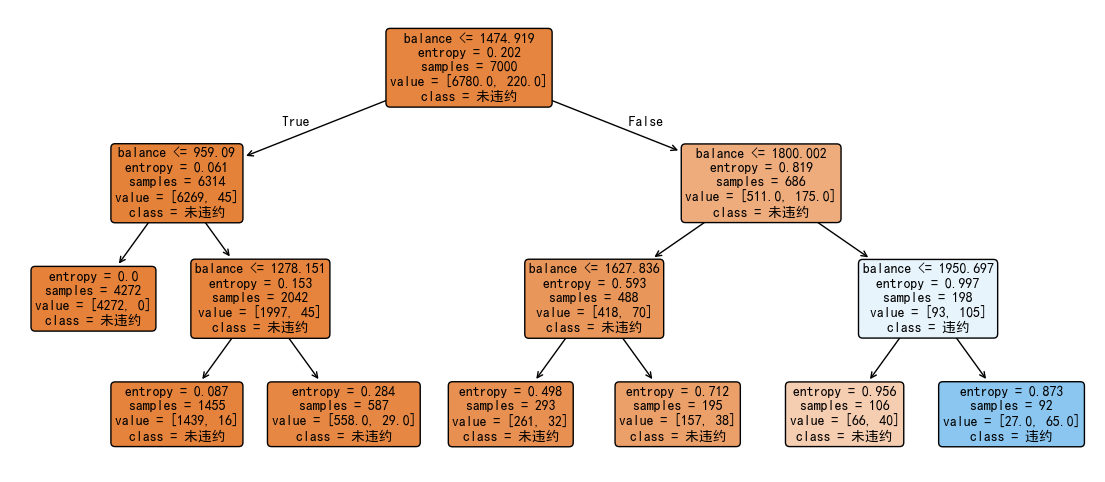

In [14]:

from sklearn.tree import DecisionTreeClassifier as DTC, plot_tree, export_text
from sklearn.model_selection import KFold, GridSearchCV
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

# --- 拟合深度为 3 的分类树（用于展示） ---
clf = DTC(criterion="entropy", max_depth=3, random_state=0)
clf.fit(X_train, y_train)

print("训练集准确率:", accuracy_score(y_train, clf.predict(X_train)))
print("测试集准确率:", accuracy_score(y_test,  clf.predict(X_test)))

# 文本展示树结构
print(export_text(clf, feature_names=["balance", "income", "student"]))

# 可视化树结构
fig, ax = plt.subplots(figsize=(14, 6))
plot_tree(clf, feature_names=["balance", "income", "student"],
          class_names=["未违约", "违约"],
          filled=True, rounded=True, ax=ax)
plt.show()


In [15]:

# --- 代价复杂度剪枝 ---
# 第一步：生长不限深度的完整树
full_clf = DTC(criterion="entropy", random_state=0)
full_clf.fit(X_train, y_train)

# 第二步：提取代价复杂度路径
ccp_path = full_clf.cost_complexity_pruning_path(X_train, y_train)
print(f"候选 alpha 值数量: {len(ccp_path.ccp_alphas)}")

# 第三步：用 5 折交叉验证选择最优 alpha
kf = KFold(n_splits=5, shuffle=True, random_state=0)
grid = GridSearchCV(
    DTC(criterion="entropy", random_state=0),
    {"ccp_alpha": ccp_path.ccp_alphas[:-1]},
    cv=kf, scoring="accuracy", refit=True
)
grid.fit(X_train, y_train)

best_clf = grid.best_estimator_
print(f"最优 alpha: {grid.best_params_['ccp_alpha']:.6f}")
print(f"最优树的叶节点数: {best_clf.get_n_leaves()}")
print(f"剪枝后测试集准确率: {accuracy_score(y_test, best_clf.predict(X_test)):.4f}")

候选 alpha 值数量: 86
最优 alpha: 0.000826
最优树的叶节点数: 8
剪枝后测试集准确率: 0.9723


### 5.3　Bagging 与随机森林



In [16]:

from sklearn.ensemble import RandomForestClassifier as RFC

# --- Bagging：max_features = p（使用全部特征）---
bagging = RFC(
    n_estimators=300,
    max_features=X_train.shape[1],  # m = p，即 Bagging
    oob_score=True,
    random_state=0
)
bagging.fit(X_train, y_train)
print(f"Bagging 测试误差: {1 - accuracy_score(y_test, bagging.predict(X_test)):.4f}")
print(f"Bagging OOB  误差: {1 - bagging.oob_score_:.4f}")

# --- 随机森林：max_features = 'sqrt'（默认，m ≈ √p）---
rf = RFC(
    n_estimators=300,
    max_features="sqrt",  # 随机森林标准设置
    oob_score=True,
    random_state=0
)
rf.fit(X_train, y_train)
print(f"随机森林 测试误差: {1 - accuracy_score(y_test, rf.predict(X_test)):.4f}")
print(f"随机森林 OOB  误差: {1 - rf.oob_score_:.4f}")

# --- 变量重要性 ---
import pandas as pd
imp = pd.Series(
    rf.feature_importances_,
    index=["balance", "income", "student"]
).sort_values(ascending=False)
print("\n变量重要性（Gini 下降量，已归一化）：")
print((imp / imp.max() * 100).round(1))


Bagging 测试误差: 0.0307
Bagging OOB  误差: 0.0321
随机森林 测试误差: 0.0307
随机森林 OOB  误差: 0.0311

变量重要性（Gini 下降量，已归一化）：
balance    100.0
income      52.1
student      0.9
dtype: float64


### 5.4　Boosting



In [17]:

from sklearn.ensemble import GradientBoostingClassifier as GBC

# --- Boosting：深度=1 的 stump，学习率=0.01 ---
boost = GBC(
    n_estimators=500,
    learning_rate=0.01,   # 学习率 λ
    max_depth=1,          # 每棵树只有一个分裂（stump）
    random_state=0
)
boost.fit(X_train, y_train)
print(f"Boosting 测试误差: {1 - accuracy_score(y_test, boost.predict(X_test)):.4f}")

# --- 用 staged_predict 观察误差随迭代次数的变化 ---
test_errors = []
for y_pred in boost.staged_predict(X_test):
    test_errors.append(1 - accuracy_score(y_test, y_pred))

# 找到测试误差最低时对应的树数量
best_n_trees = np.argmin(test_errors) + 1
print(f"测试误差最低时的树数量: {best_n_trees}")
print(f"对应的最低测试误差: {test_errors[best_n_trees - 1]:.4f}")


Boosting 测试误差: 0.0293
测试误差最低时的树数量: 143
对应的最低测试误差: 0.0293


---

## 小结

本章从最简单的分组均值出发，逐步建立了对决策树和集成方法的理解。核心知识链条为：

$$
\text{分组均值}
\longrightarrow
\text{虚拟变量回归}
\longrightarrow
\text{单棵决策树}
\longrightarrow
\underbrace{\text{Bagging} \to \text{随机森林} \to \text{Boosting}}_{\text{集成方法：降低方差/偏差，提升预测精度}}
$$

**关键结论**：

1. 决策树是分组均值预测的推广，通过递归二叉分裂自动寻找最优分组边界
2. 单棵树的高方差问题通过集成方法（Bagging、随机森林、Boosting）得到有效解决
3. 随机森林在 Bagging 基础上引入特征随机化，进一步去相关，是实践中最常用的方法之一
4. Boosting 通过顺序学习和慢收缩逐步修正残差，是目前预测精度最高的集成方法之一，但需要仔细调参（尤其是 $B$ 和 $\lambda$）
5. 无论哪种方法，`balance`（信用卡余额）都是预测违约最重要的特征——与描述统计的直觉完全一致

---

## 附录 A　虚拟变量回归与分组均值的等价性

设 $D_i \in \{0, 1\}$ 为二值虚拟变量，$n_0$ 和 $n_1$ 分别为两组的样本量，$n = n_0 + n_1$。

OLS 最小化目标函数为
$$
Q(\alpha, \beta) = \sum_{i=1}^{n} (y_i - \alpha - \beta D_i)^2
$$

对 $\alpha$ 和 $\beta$ 分别求偏导并令其为零，得到正规方程组：
$$
\frac{\partial Q}{\partial \alpha} = -2 \sum_i (y_i - \hat{\alpha} - \hat{\beta} D_i) = 0
\implies \bar{y} = \hat{\alpha} + \hat{\beta} \bar{D}
$$
$$
\frac{\partial Q}{\partial \beta} = -2 \sum_i D_i (y_i - \hat{\alpha} - \hat{\beta} D_i) = 0
\implies \frac{1}{n_1}\sum_{D_i=1} y_i = \hat{\alpha} + \hat{\beta}
$$

由第二个方程：$\hat{\alpha} + \hat{\beta} = \bar{y}_{D=1}$。

代入第一个方程：$\hat{\alpha} = \bar{y} - \hat{\beta} \bar{D} = \bar{y} - (\bar{y}_{D=1} - \hat{\alpha}) \cdot \frac{n_1}{n}$，解得 $\hat{\alpha} = \bar{y}_{D=0}$。

因此：
- 对 $D_i = 0$ 的样本，OLS 拟合值为 $\hat{\alpha} = \bar{y}_{D=0}$
- 对 $D_i = 1$ 的样本，OLS 拟合值为 $\hat{\alpha} + \hat{\beta} = \bar{y}_{D=1}$

**结论**：OLS 拟合值恰好等于各组的样本均值，与决策树叶节点预测值完全一致。$\square$

## 附录 B　递归二叉分裂算法的伪代码

```
输入：训练集 {(x_i, y_i), i=1,...,n}，最小叶节点样本数 min_samples
输出：决策树 T

函数 grow_tree(数据 S):
    如果 |S| < min_samples，返回叶节点（预测值 = mean(y in S)）
    
    best_rss = ∞
    best_j, best_s = None, None
    
    对每个特征 j = 1, ..., p:
        对特征 j 的每个候选切分点 s:
            S_left  = {(x_i, y_i) ∈ S | x_ij < s}
            S_right = {(x_i, y_i) ∈ S | x_ij ≥ s}
            rss = RSS(S_left) + RSS(S_right)   # 公式 (2.2)
            如果 rss < best_rss:
                best_rss = rss
                best_j, best_s = j, s
    
    按 (best_j, best_s) 将 S 分为 S_left 和 S_right
    返回内部节点 {特征: best_j, 阈值: best_s,
                左子树: grow_tree(S_left),
                右子树: grow_tree(S_right)}

T = grow_tree(训练集)
```

**时间复杂度**：对每个节点，遍历所有特征和切分点的复杂度为 $O(np)$（$n$ 个候选切分点，$p$ 个特征）。树的深度最大为 $O(\log n)$（均衡情形）到 $O(n)$（退化情形），因此总复杂度约为 $O(np \log n)$。

## 附录 C　贝叶斯加法回归树（BART）简介

贝叶斯加法回归树（Bayesian Additive Regression Trees，BART）是一种将贝叶斯方法与树集成思想结合的方法，兼具 Bagging 的随机性和 Boosting 的顺序残差拟合特性。

**基本思路**：假设目标函数可以写成 $K$ 棵小树的加和：

$$
f(x) = \sum_{k=1}^{K} f_k(x)
$$

BART 通过 Markov Chain Monte Carlo（MCMC）方法在所有可能的树结构上进行贝叶斯采样，得到一系列预测模型的集合，最终取平均作为点预测，取分位数作为不确定性度量。

**主要特点**：

- 开箱即用（out-of-box）性能强，调参需求少；典型设置：$K=200$，$B=1000$，丢弃前 $L=100$ 次烧入（burn-in）迭代
- 自然提供预测的不确定性区间（后验分布的分位数），在风险管理等需要量化不确定性的场景中有优势
- 与 Boosting 不同，BART 对每棵树的更新是随机扰动而非从头拟合残差，有助于避免局部最优
- 计算成本高于随机森林和 Boosting，适合作为对比基准或在精度要求极高时使用

Python 实现可通过 `ISLP.bart.BART` 调用。本课程将 BART 作为扩展内容，不作为考核重点。

## 参考文献

- James, G., Witten, D., Hastie, T., Tibshirani, R., & Taylor, J. (2023). *An Introduction to Statistical Learning: with Applications in Python* (2nd ed.). Springer. Chapter 8. [Link](https://www.statlearning.com/)
- Breiman, L. (1996). Bagging predictors. *Machine Learning*, 24(2), 123–140. [Link](https://doi.org/10.1007/BF00058655)
- Breiman, L. (2001). Random forests. *Machine Learning*, 45(1), 5–32. [Link](https://doi.org/10.1023/A:1010933404324)
- Friedman, J. H. (2001). Greedy function approximation: A gradient boosting machine. *Annals of Statistics*, 29(5), 1189–1232. [Link](https://doi.org/10.1214/aos/1013203451)
- Chipman, H. A., George, E. I., & McCulloch, R. E. (2010). BART: Bayesian additive regression trees. *Annals of Applied Statistics*, 4(1), 266–298. [Link](https://doi.org/10.1214/09-AOAS285)